In [ ]:
!nvidia-smi

Sat Oct  3 12:56:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -U unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.1/26.1 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 134.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 128.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 115.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/216.9 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19

In [ ]:
import torch

print("GPU:", torch.cuda.get_device_name(0))
print("CUDA available:", torch.cuda.is_available())

GPU: Tesla T4
CUDA available: True


SFT-SUPERVISED FINE TUNING

In [ ]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen3-0.6B",
    max_seq_length=1024,
    load_in_4bit=True,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.14: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 7.5. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

| Code                                    | Simple meaning                                                   |
| --------------------------------------- | ---------------------------------------------------------------- |
| `from unsloth import FastLanguageModel` | Import Unsloth's tool for working with language models.          |
| `model, tokenizer =`                    | Get two things: the **model** and the **tokenizer**.             |
| `FastLanguageModel.from_pretrained(`    | Load an **already-trained** model.                               |
| `model_name="unsloth/Qwen3-0.6B"`       | Choose the **Qwen3-0.6B** model (~600M parameters).              |
| `max_seq_length=1024`                   | Allow each input/training example to have up to **1024 tokens**. |
| `load_in_4bit=True`                     | Load the model in **4-bit** to use less GPU memory.              |
| `)`                                     | Finish the function call.                                        |


In [ ]:
from datasets import load_dataset
dataset = load_dataset("xlangai/spider")


README.md:   0%|          | 0.00/5.51k [00:00<?, ?B/s]

spider/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  831kB            

spider/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

spider/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  126kB            

spider/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/7000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1034 [00:00<?, ? examples/s]

| Part             | Meaning                        |
| ---------------- | ------------------------------ |
| `xlangai/spider` | Spider Text-to-SQL dataset     |
| `load_dataset()` | Downloads the dataset          |
| `dataset`        | Stores it for our SFT training |


In [ ]:
print(dataset)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['db_id', 'query', 'question', 'query_toks', 'query_toks_no_value', 'question_toks'],
        num_rows: 7000
    })
    validation: Dataset({
        features: ['db_id', 'query', 'question', 'query_toks', 'query_toks_no_value', 'question_toks'],
        num_rows: 1034
    })
})
{'db_id': 'department_management', 'query': 'SELECT count(*) FROM head WHERE age  >  56', 'question': 'How many heads of the departments are older than 56 ?', 'query_toks': ['SELECT', 'count', '(', '*', ')', 'FROM', 'head', 'WHERE', 'age', '>', '56'], 'query_toks_no_value': ['select', 'count', '(', '*', ')', 'from', 'head', 'where', 'age', '>', 'value'], 'question_toks': ['How', 'many', 'heads', 'of', 'the', 'departments', 'are', 'older', 'than', '56', '?']}


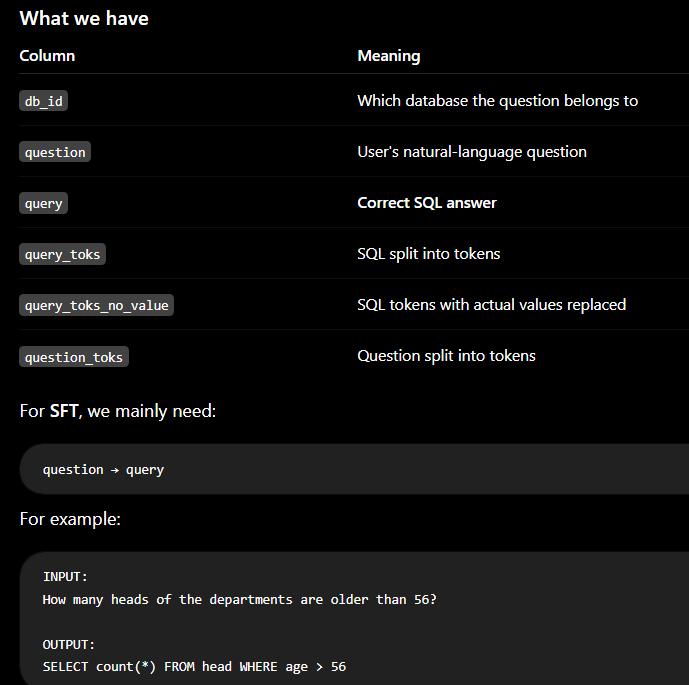

In [ ]:
def format_example(example):
    return {
        "text": f"""### Question:
{example["question"]}

### Answer:
{example["query"]}"""
    }

dataset = dataset.map(format_example)

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1034 [00:00<?, ? examples/s]

| Code                           | Meaning                                                   |
| ------------------------------ | --------------------------------------------------------- |
| `def format_example(example):` | Create a function to format **one example**               |
| `example["question"]`          | Get the question                                          |
| `example["query"]`             | Get the correct SQL                                       |
| `"text"`                       | Create a new field containing our formatted training text |
| `dataset.map(...)`             | Apply this function to **every example**                  |


In [ ]:
print(dataset["train"][0]["text"])

### Question:
How many heads of the departments are older than 56 ?

### Answer:
SELECT count(*) FROM head WHERE age  >  56


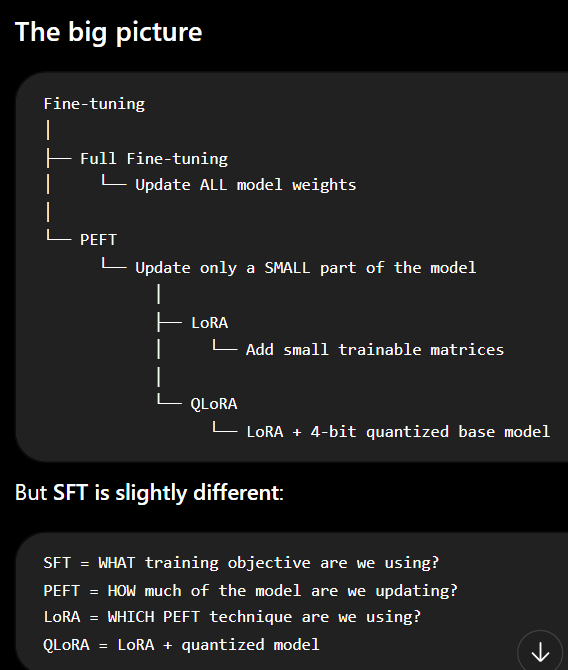

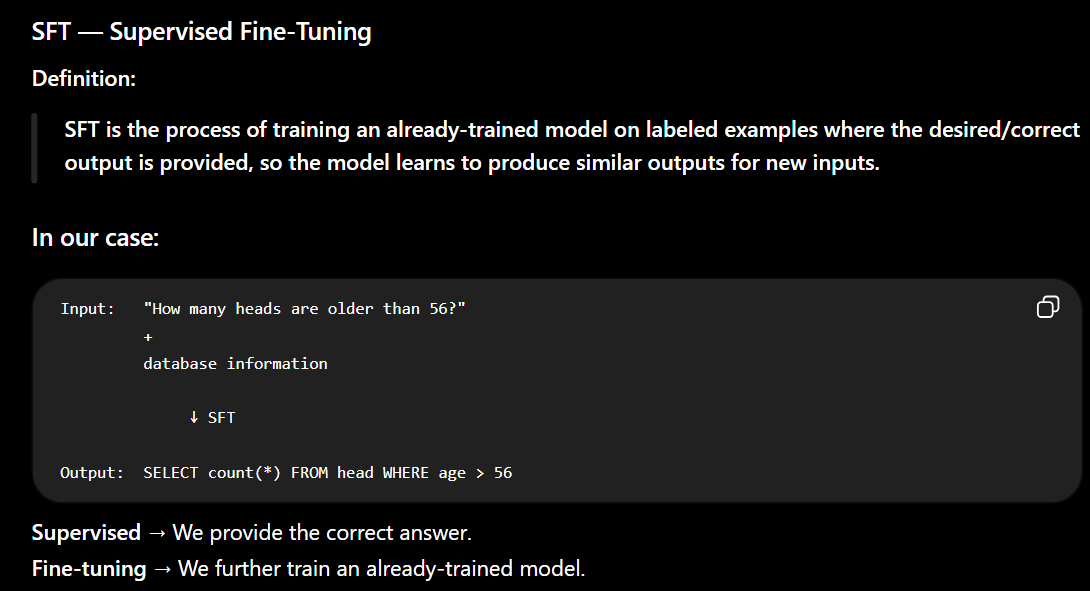

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=16,
    lora_dropout=0,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
    ],
)

Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.9.14 patched 28 layers with 28 QKV layers, 28 O layers and 0 MLP layers.


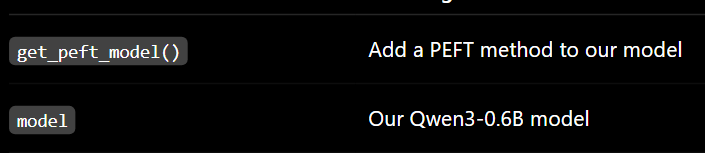
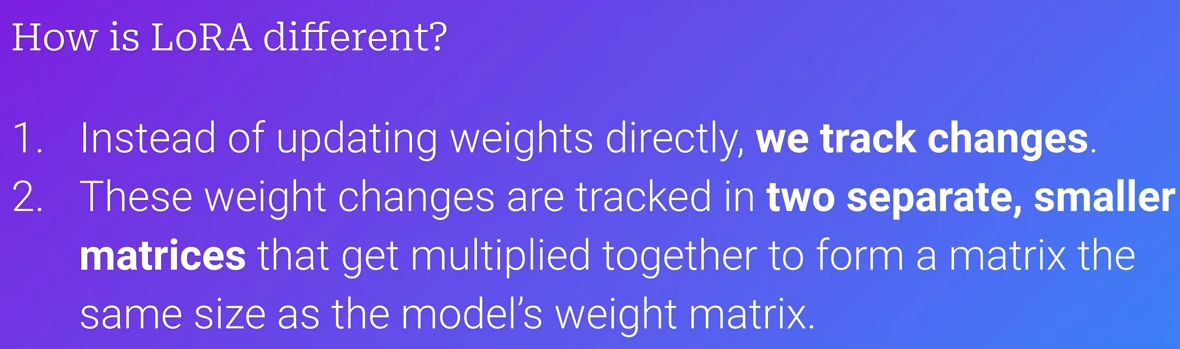
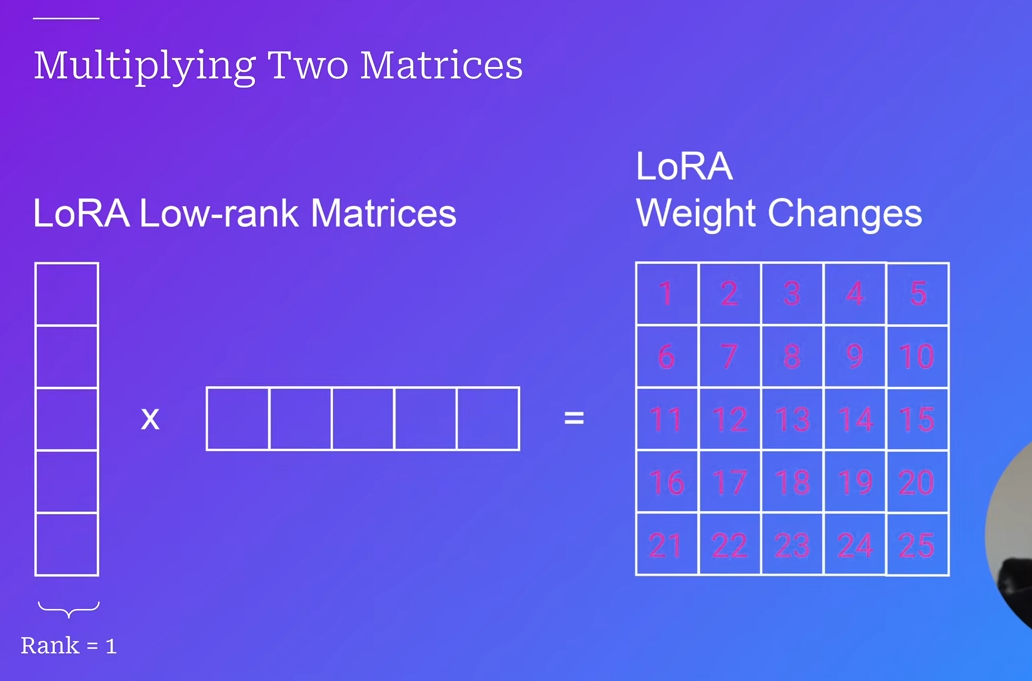

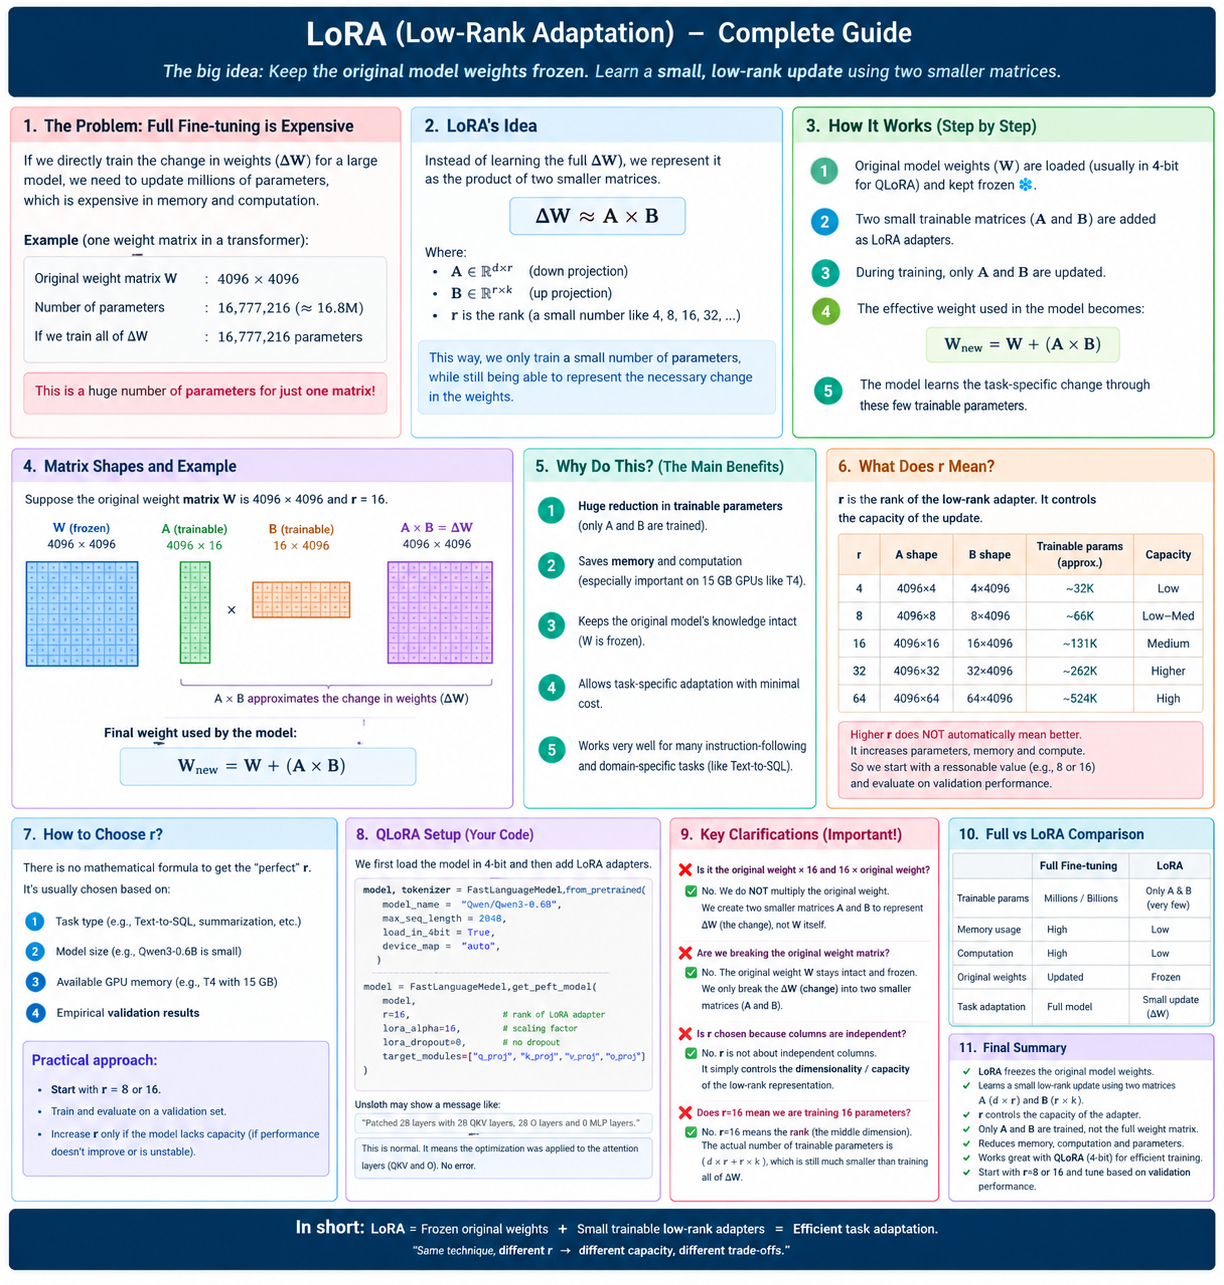

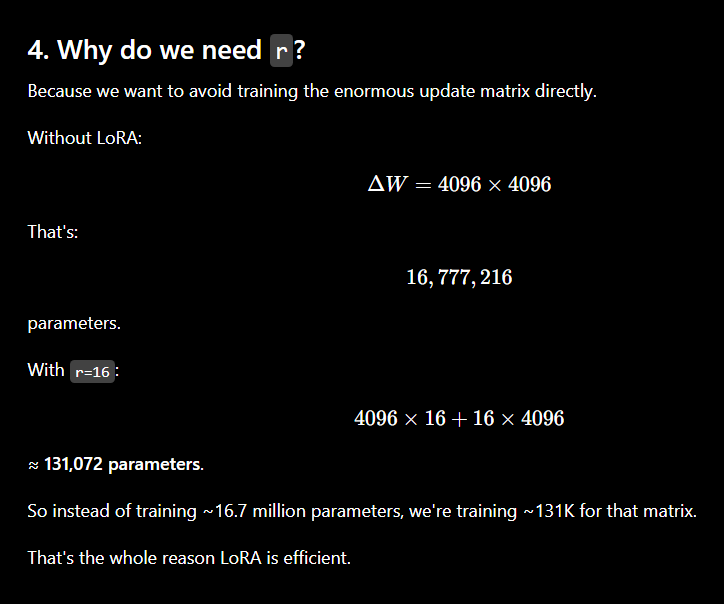
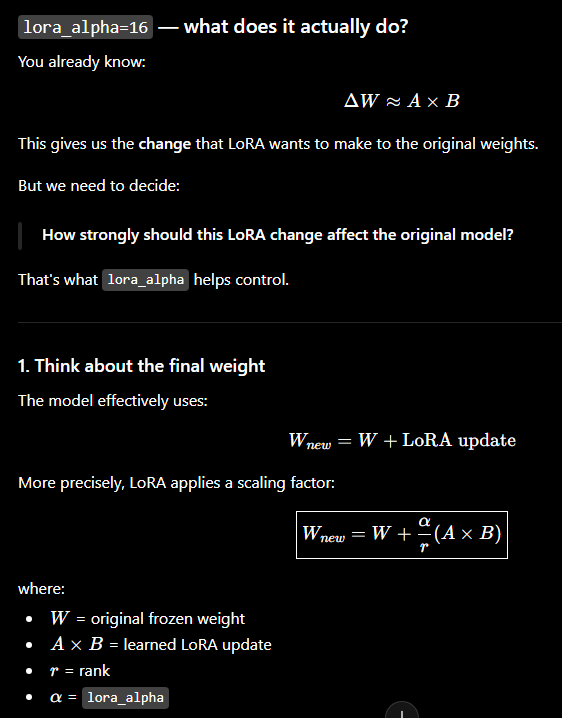
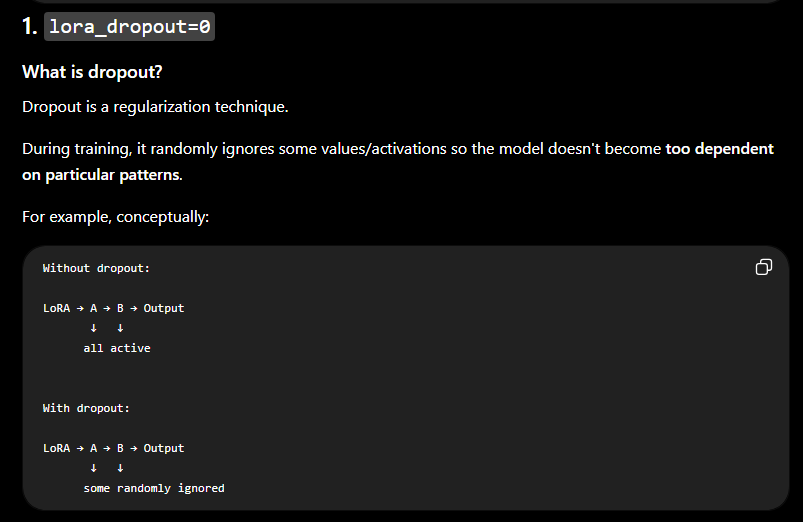
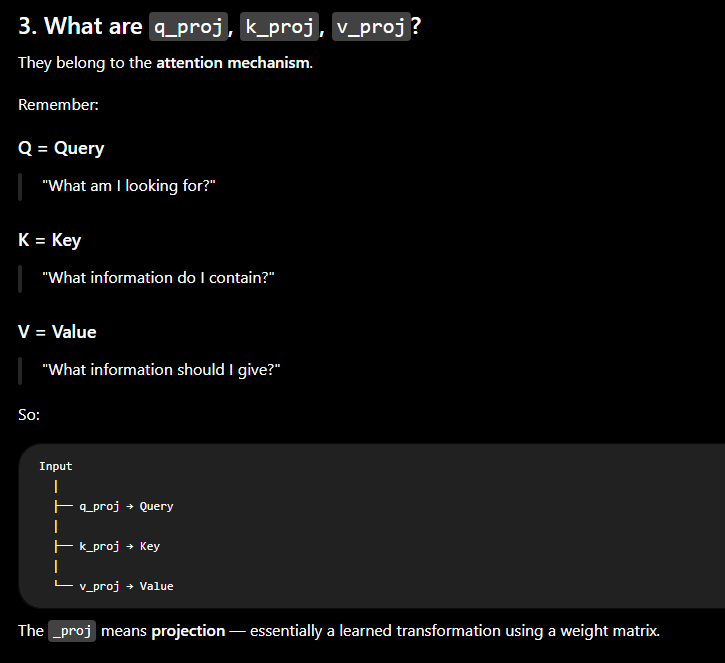


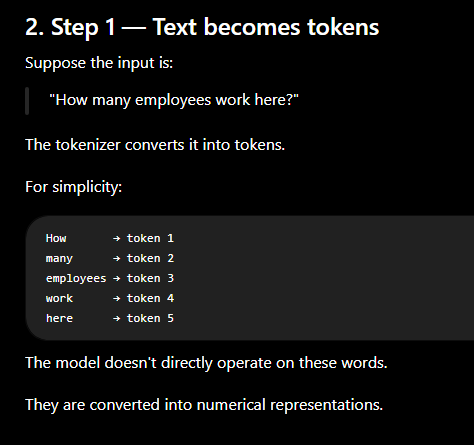
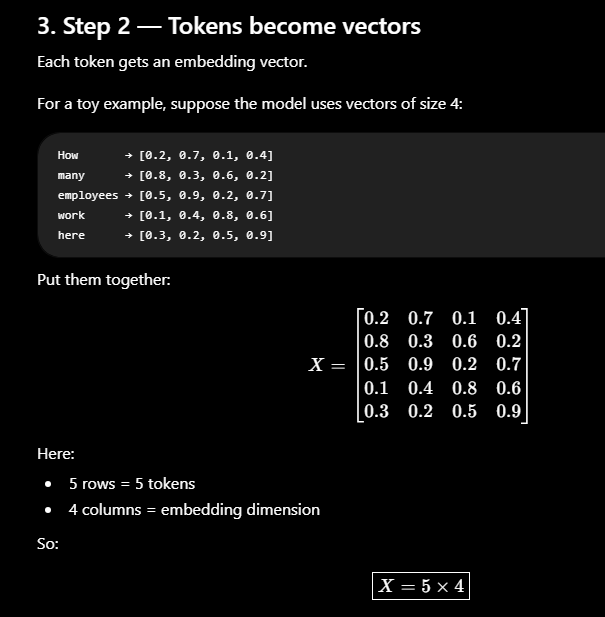
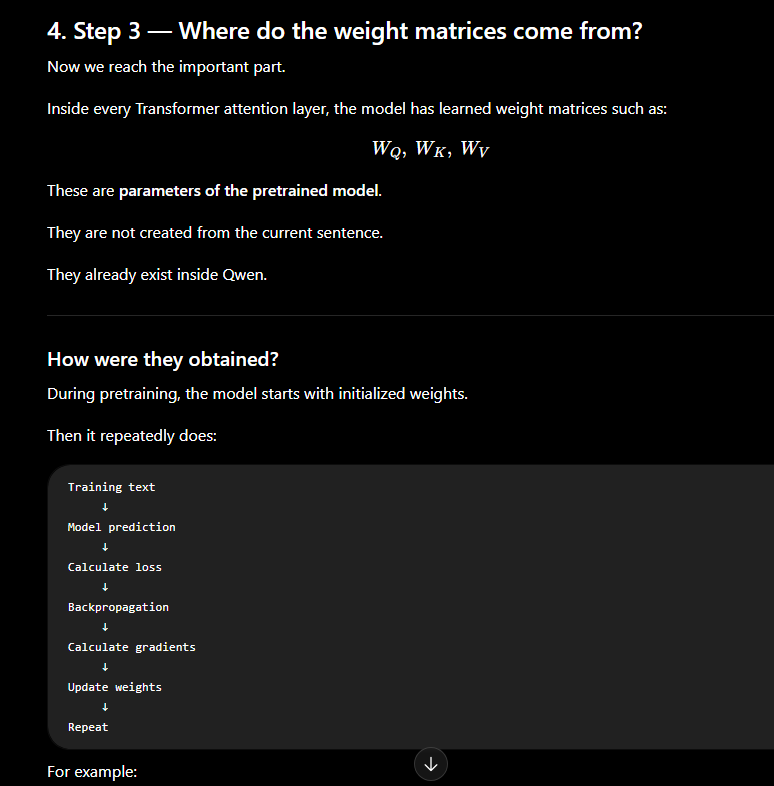
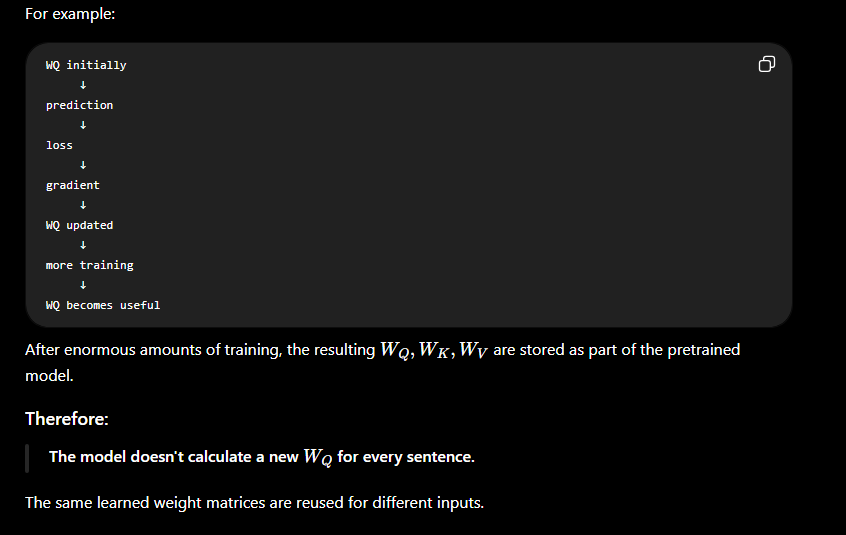
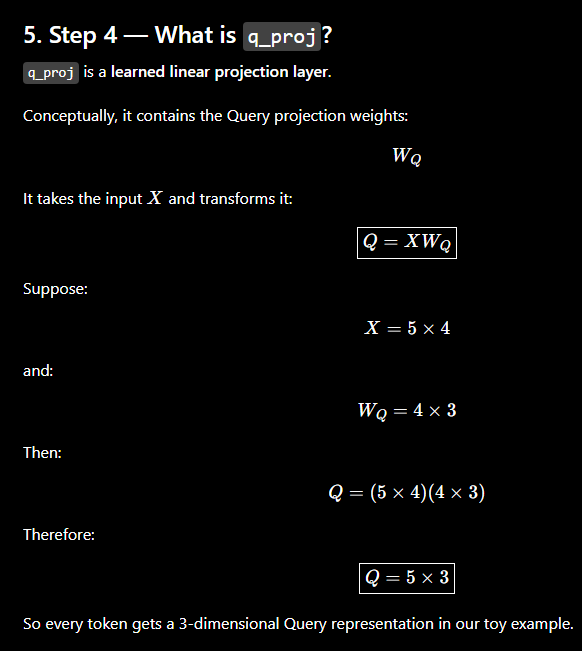
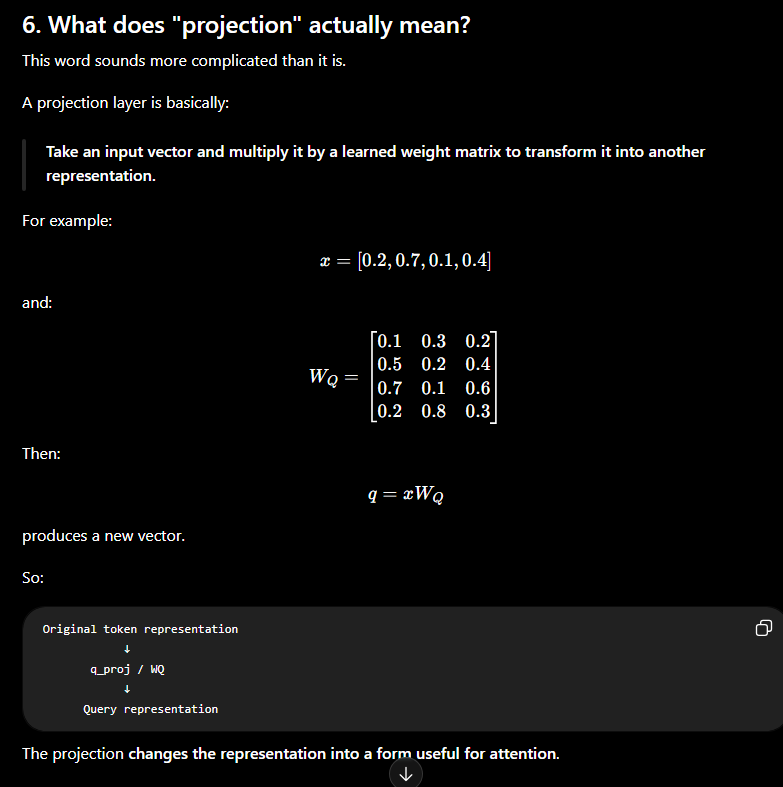
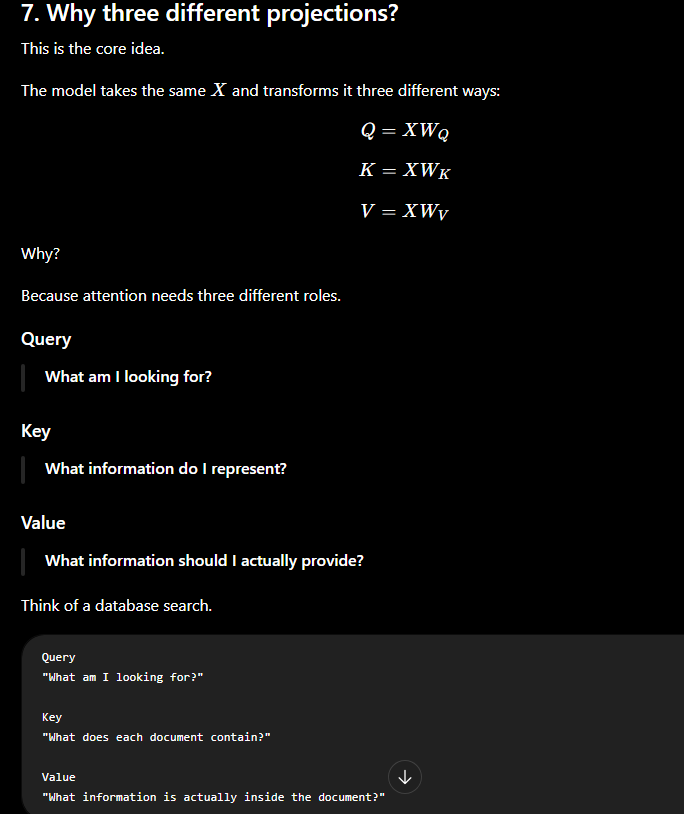


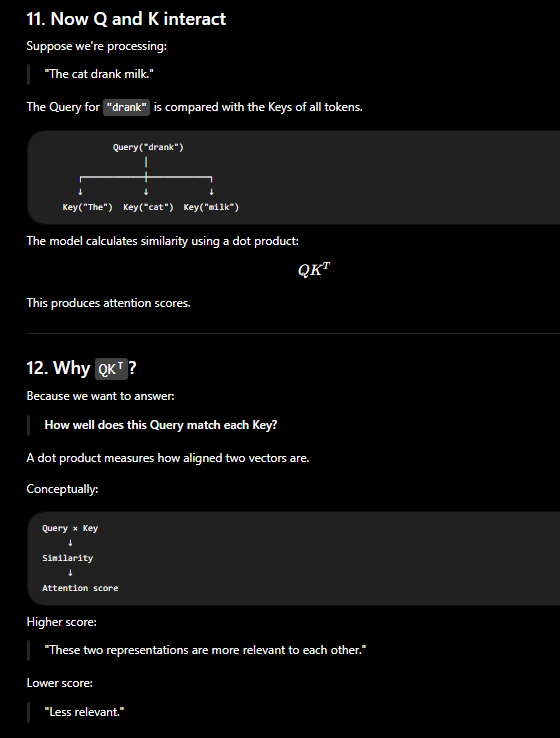
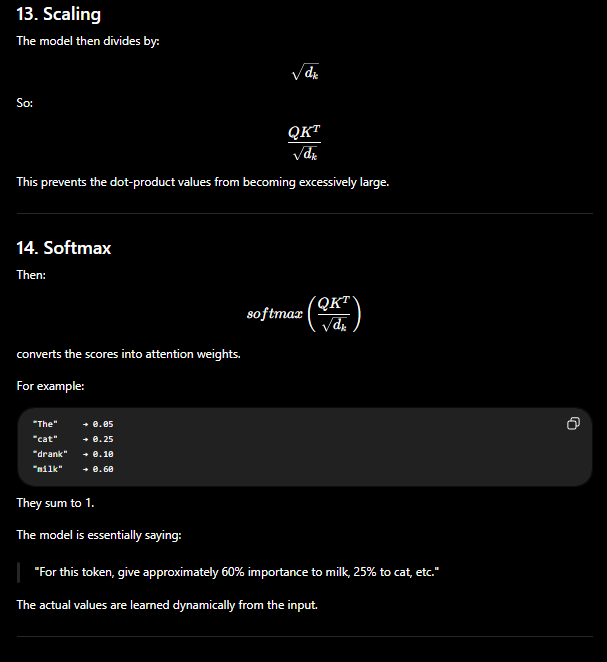
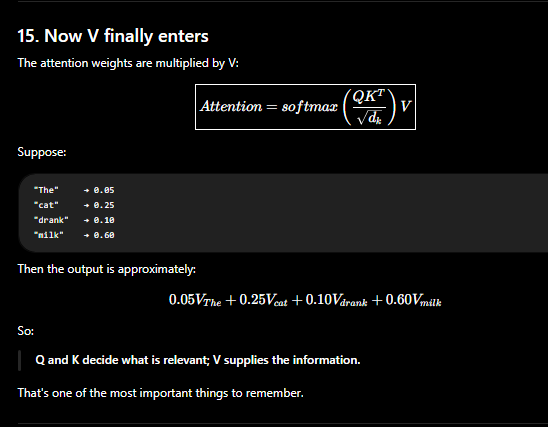
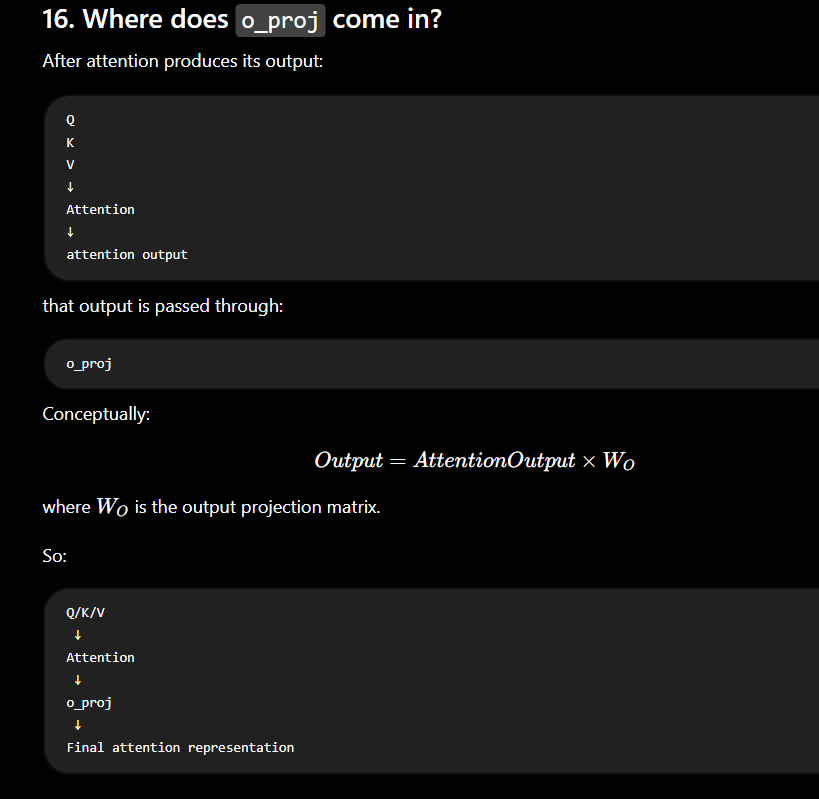
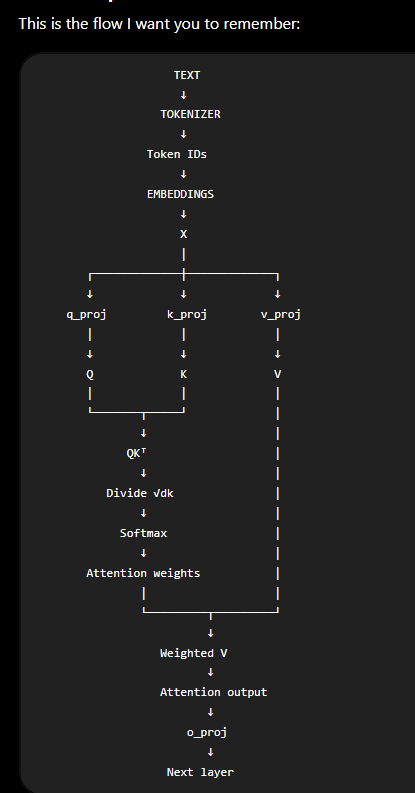


In [ ]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    processing_class=tokenizer,

    args=SFTConfig(
        output_dir="outputs",
        max_length=1024,

        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,

        learning_rate=2e-4,
        num_train_epochs=1,

        logging_steps=10,
        eval_strategy="steps",
        eval_steps=50,

        fp16=True,
        optim="adamw_8bit",

        report_to="none",
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/7000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/1034 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


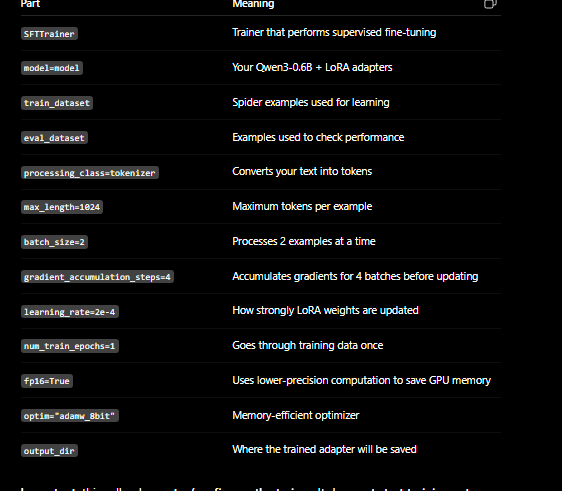

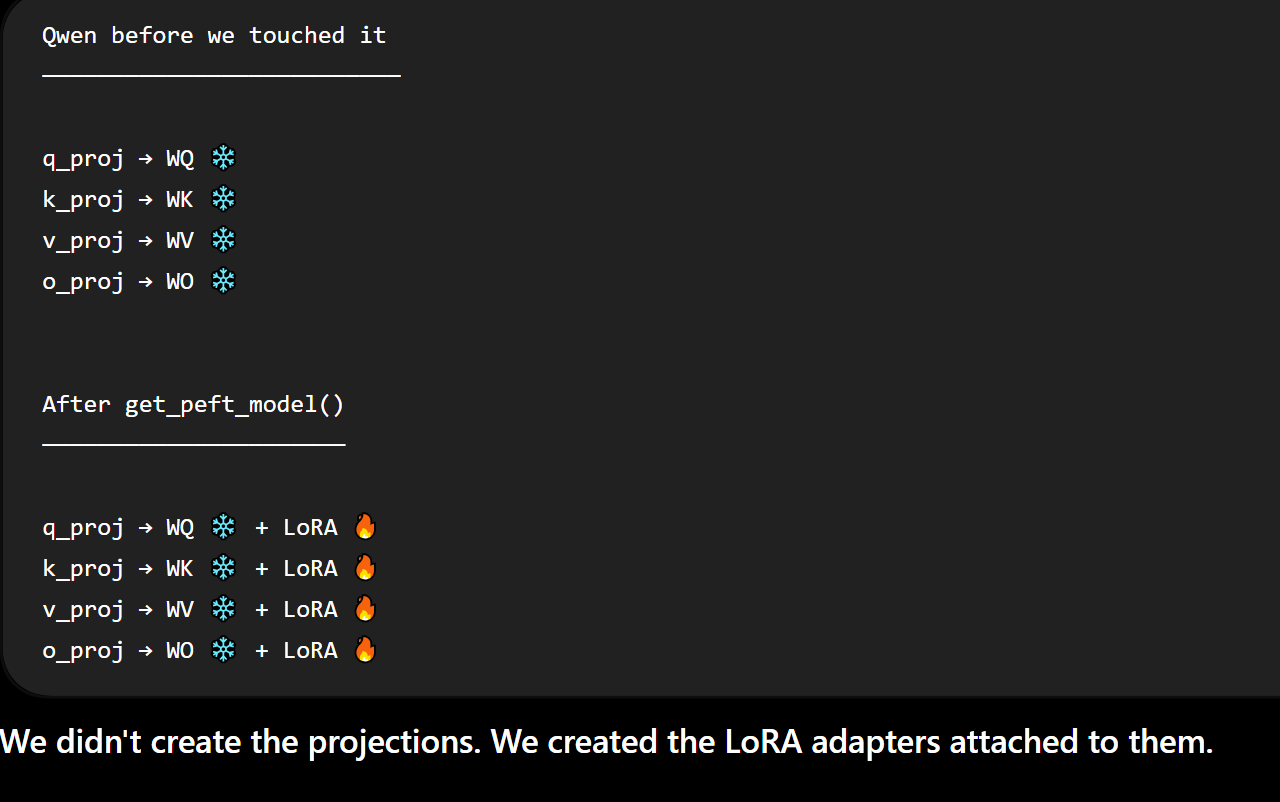

In [ ]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 7,000 | Num Epochs = 1 | Total steps = 875
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 4,587,520 of 600,637,440 (0.76% trained)


Step,Training Loss,Validation Loss
50,0.942748,1.386279
100,0.918890,1.404301
150,0.980417,1.424355
200,0.912773,1.451433
250,0.875694,1.442013
300,0.917191,1.434300
350,0.872973,1.447162
400,0.851431,1.448490
450,0.830909,1.437623
500,0.881301,1.436517


TrainOutput(global_step=875, training_loss=0.8982936701093401, metrics={'train_runtime': 1691.6182, 'train_samples_per_second': 4.138, 'train_steps_per_second': 0.517, 'total_flos': 980993738539008.0, 'train_loss': 0.8982936701093401, 'epoch': 1.0})

In [ ]:
import re

def extract_sql(text):
    # Take only what comes after ### Answer:
    if "### Answer:" in text:
        text = text.split("### Answer:", 1)[1]

    # Remove anything after another section
    if "###" in text:
        text = text.split("###", 1)[0]

    # Remove semicolon
    text = text.replace(";", "")

    # Normalize whitespace
    text = " ".join(text.split())

    return text.strip().lower()


correct = 0
total = 100

for i in range(total):

    example = dataset["validation"][i]

    prompt = f"""### Question:
{example["question"]}

### Answer:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False
    )

    generated = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    predicted_sql = extract_sql(generated)
    actual_sql = extract_sql(example["query"])

    if predicted_sql == actual_sql:
        correct += 1

print("Correct:", correct)
print("Total:", total)
print("Exact Match Accuracy:", correct / total)

Correct: 11
Total: 100
Exact Match Accuracy: 0.11
